In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


<div style="
    background-color: #f0f4f8; 
    padding: 30px; 
    border-radius: 15px; 
    font-family: Arial, sans-serif; 
    position: relative;
    overflow: hidden;
">
   

 <!-- Content -->
<div style="position: relative; z-index: 1;">
        <h1 style="color:#2c3e50; text-align:center;">🎬 Welcome to the Cinema Audience Forecasting Notebook</h1>
        <p style="font-size:16px; color:#34495e; text-align:center; margin-top:10px;">
            In this notebook, we explore and forecast <strong>daily cinema audience counts</strong> across multiple theatres using both online and point-of-sale booking data.
        </p>

<hr style="margin:25px 0; border:1px solid #dfe6e9;">

 <h2 style="color:#2c3e50; text-align:center;">📂 Challenge Overview</h2>
        <p style="color:#34495e; font-size:15px;">
            The goal of the <strong>Cinema Audience Forecasting Challenge</strong> is to accurately predict daily theatre audience counts using historical booking and visit data.
        </p>

<h2 style="color:#2c3e50; text-align:center;">🗂️ Provided Datasets</h2>
        <ul style="color:#34495e; font-size:15px;">
            <li><strong>cinePOS_theaters.csv</strong> – CinePOS theatre info</li>
            <li><strong>booknow_theaters.csv</strong> – BookNow theatre info</li>
            <li><strong>movie_theater_id_relation.csv</strong> – Mapping between BookNow and CinePOS theatres</li>
            <li><strong>cinePOS_booking.csv</strong> – CinePOS bookings</li>
            <li><strong>booknow_booking.csv</strong> – BookNow bookings</li>
            <li><strong>booknow_visits.csv</strong> – Daily audience counts</li>
            <li><strong>date_info.csv</strong> – Calendar information</li>
            <li><strong>sample_submission.csv</strong> – Submission format</li>
        </ul>
<h4 style="color:#2c3e50; text-align:center;">We will mostly use booknow_visits dataset as it provides the most complete information</h4>
<h2 style="color:#2c3e50; text-align:center; margin-top:30px;">🚀 Let's start exploring and forecasting!</h2>
    </div>
</div>


In [2]:
bnbook = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
bntheater = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
bnvisit = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
cpbook = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cptheater = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
dateinfo = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
mtr = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
ss = pd.read_csv(f"/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

In [3]:
#libraries:

import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
ds = {
    'bnbook': bnbook,
    'bntheater': bntheater,
    'bnvisit': bnvisit,
    'cpbook': cpbook,
    'cptheater': cptheater,
    'dateinfo': dateinfo,
    'mtr': mtr,
    'ss': ss
}

In [5]:
insights = {
    "bnbook": "Bookings dataset with show & booking timestamps. 68k rows.",
    "bntheater": "Theater metadata; missing book_theater_id for more than 50% rows.",
    "bnvisit": "Visit-level audience counts; 214k rows across show dates.",
    "cpbook": "CinePOS booking data; large dataset with 1.6M rows.",
    "cptheater": "CinePOS theater metadata; latitude/longitude missing in many rows.",
    "dateinfo": "Calendar mapping of show_date to day_of_week.",
    "mtr": "Mapping table linking book_theater_id and cine_theater_id.",
    "ss": "Synthetic dataset containing ID + audience_count for submission.",
}


In [6]:
def inspect_datasets(ds):
    for name, df in ds.items():
        print("\n" + "="*120)
        print(f" Dataset: {name} {df.shape}")
        print(f" Columns: {list(df.columns)}\n")
    
        display(df.head(), df.info())
    
        print("\n📌 INSIGHT:", insights[name])
        print("="*120)

  

In [7]:
# --- bnbook ---
bnbook.rename(columns={'show_datetime': 'show_date'}, inplace=True)

bnbook['show_date'] = pd.to_datetime(bnbook['show_date'], errors='coerce')
bnbook['booking_datetime'] = pd.to_datetime(bnbook['booking_datetime'], errors='coerce')

# --- bnvisit ---
bnvisit['show_date'] = pd.to_datetime(bnvisit['show_date'], errors='coerce')

# --- cpbook ---
cpbook.rename(columns={'show_datetime': 'show_date'}, inplace=True)

cpbook['show_date'] = pd.to_datetime(cpbook['show_date'], errors='coerce')
cpbook['booking_datetime'] = pd.to_datetime(cpbook['booking_datetime'], errors='coerce')

# --- dateinfo ---
dateinfo['show_date'] = pd.to_datetime(dateinfo['show_date'], errors='coerce')


In [8]:
inspect_datasets(ds)



 Dataset: bnbook (68336, 4)
 Columns: ['book_theater_id', 'show_date', 'booking_datetime', 'tickets_booked']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   book_theater_id   68336 non-null  object        
 1   show_date         68336 non-null  datetime64[ns]
 2   booking_datetime  68336 non-null  datetime64[ns]
 3   tickets_booked    68336 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 2.1+ MB


,book_theater_id,show_date,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


None


📌 INSIGHT: Bookings dataset with show & booking timestamps. 68k rows.

 Dataset: bntheater (829, 5)
 Columns: ['book_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515


...

None


📌 INSIGHT: Mapping table linking book_theater_id and cine_theater_id.

 Dataset: ss (38062, 2)
 Columns: ['ID', 'audience_count']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              38062 non-null  object
 1   audience_count  38062 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 594.8+ KB


,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


None


📌 INSIGHT: Synthetic dataset containing ID + audience_count for submission.


<h1 style="color:#2D89C1; font-family:Arial, sans-serif; text-align:center;">
    📊 Analysing BOOKNOW VISIT
</h1>


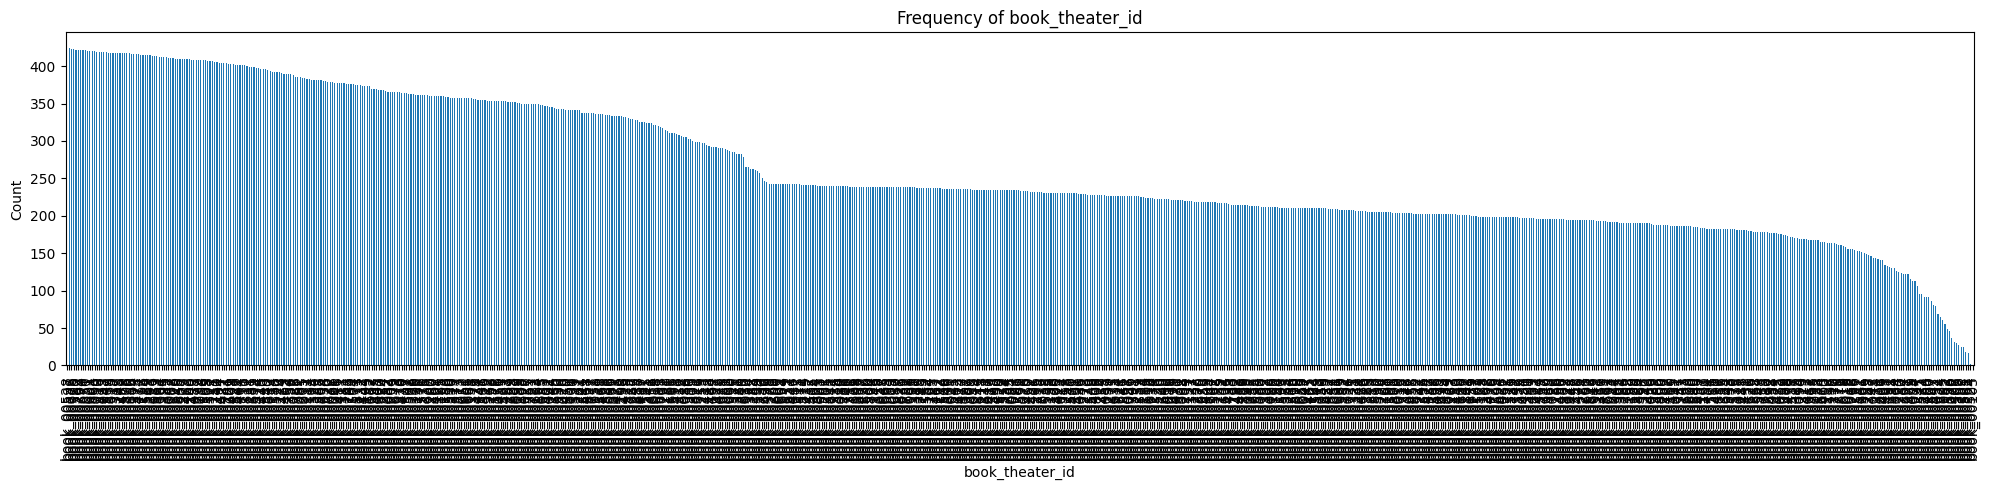

In [9]:
bnvisit.book_theater_id.value_counts().plot(kind='bar', figsize=(20, 5))
plt.title("Frequency of book_theater_id")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


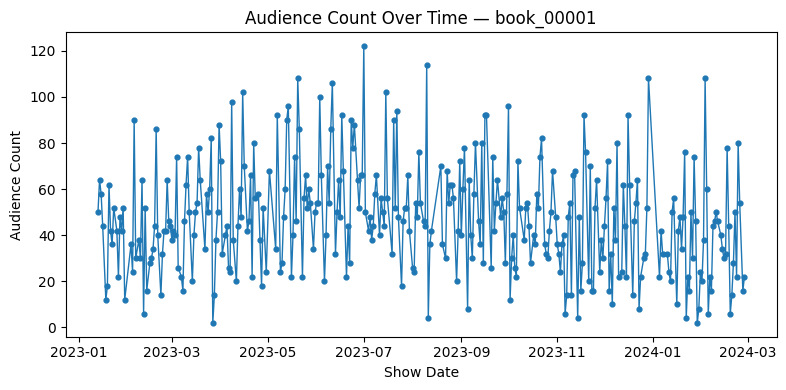

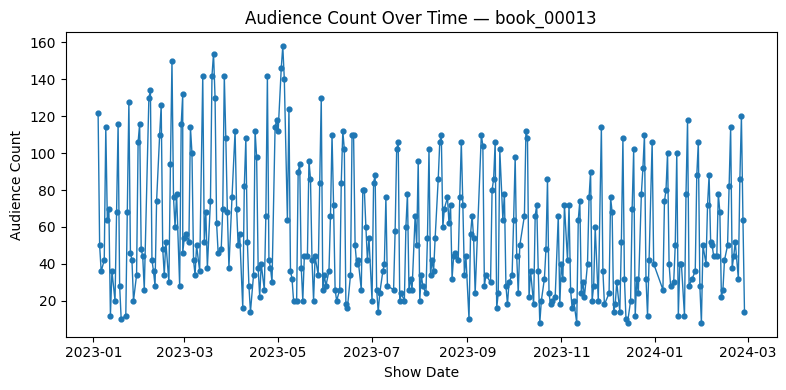

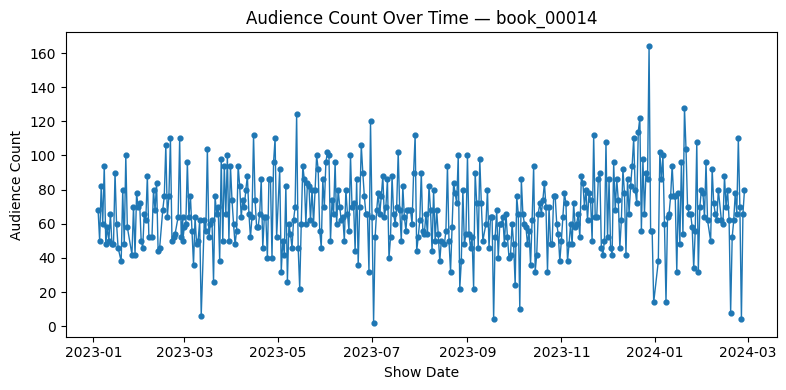

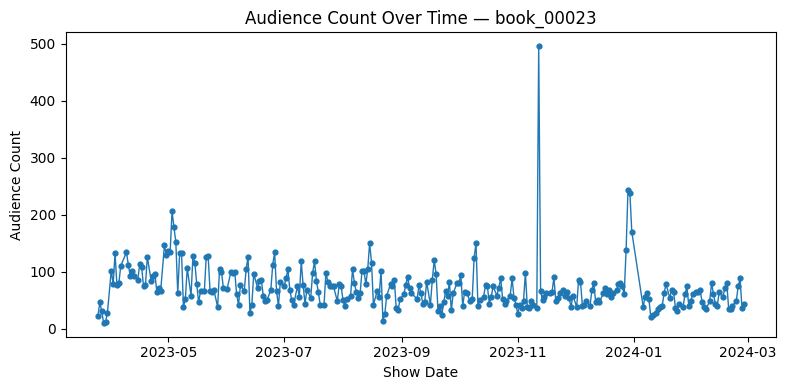

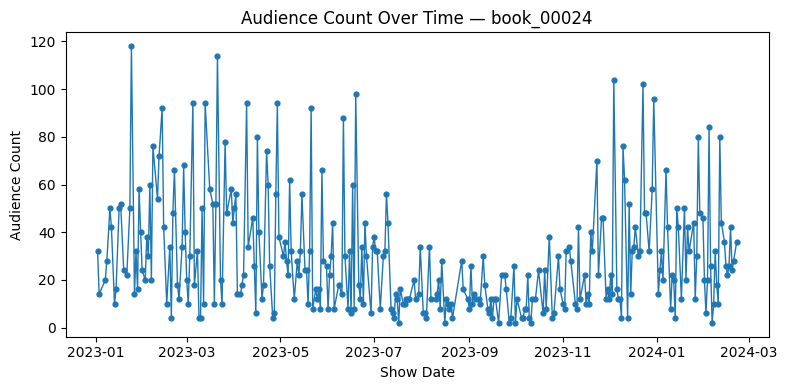

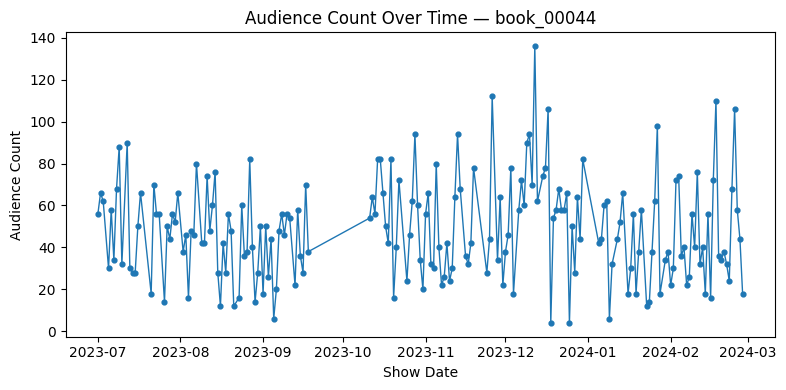

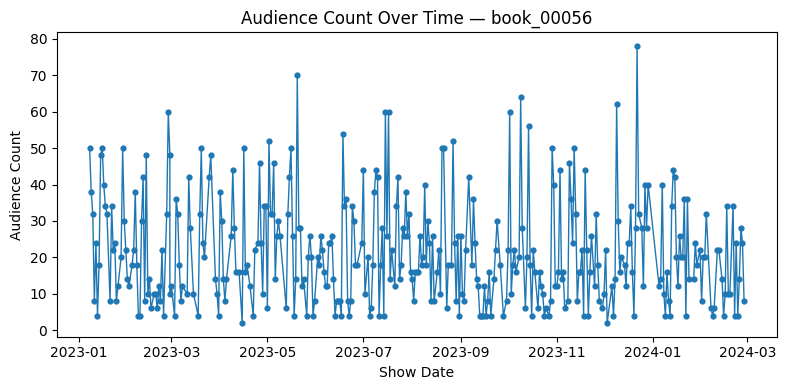

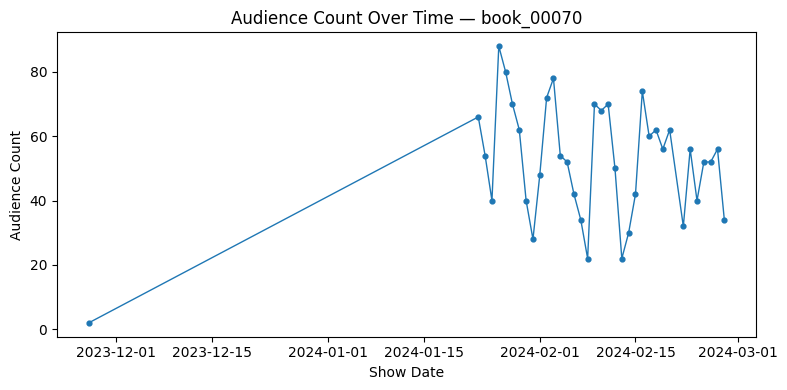

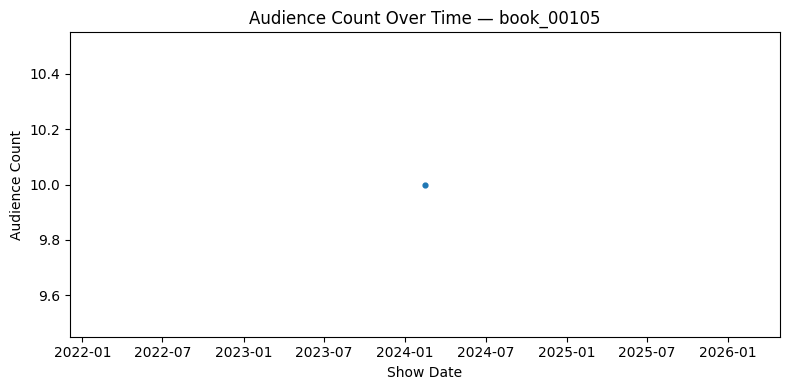

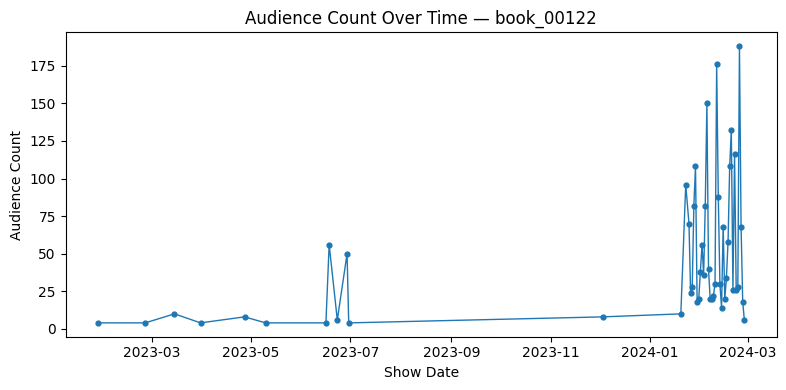

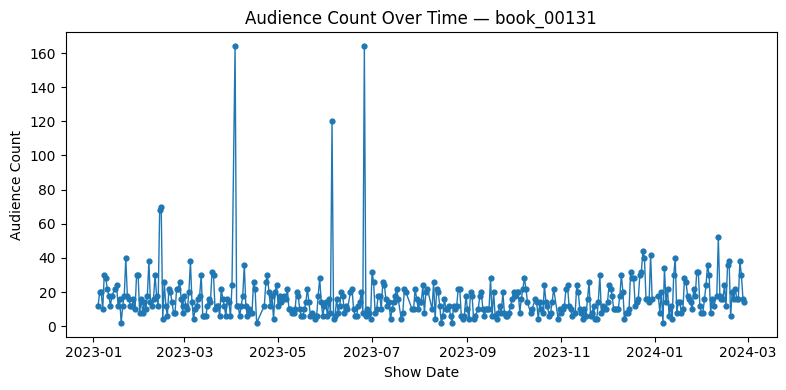

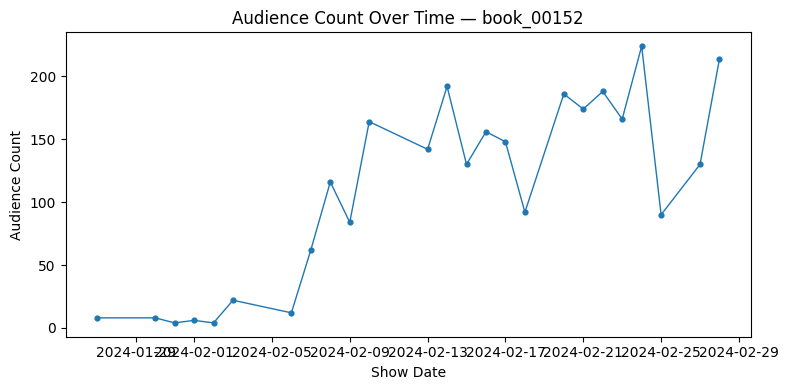

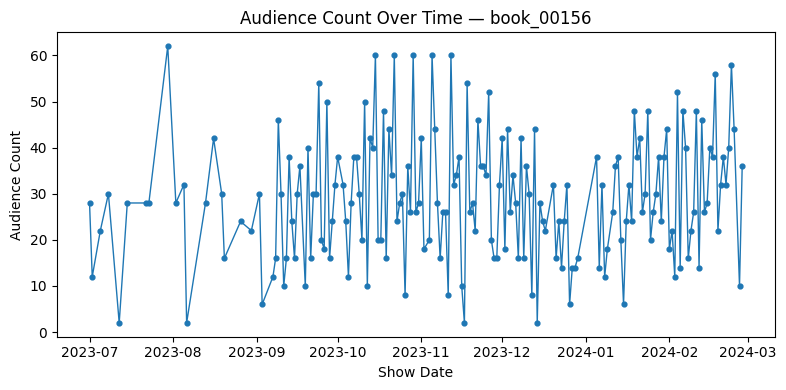

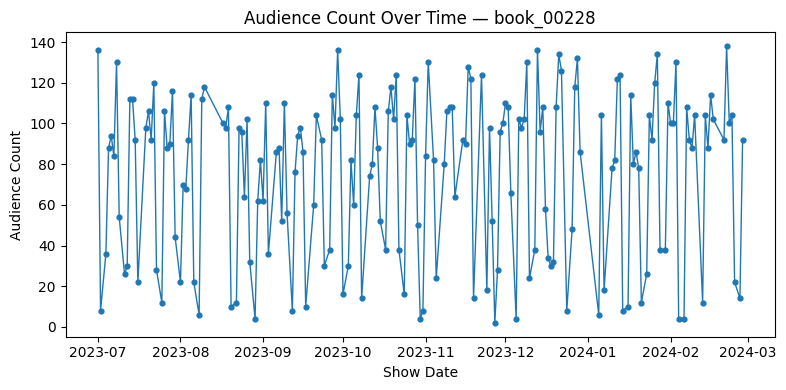

In [10]:
theaters_to_plot = [
    'book_00001', 'book_00013', 'book_00014', 'book_00023',
    'book_00024', 'book_00044', 'book_00056', 'book_00070', 'book_00105',
    'book_00122', 'book_00131', 'book_00152', 'book_00156', 'book_00228'
]
for theater in theaters_to_plot:
    df = bnvisit[bnvisit['book_theater_id'] == theater].sort_values('show_date')
    if df.empty:
        continue
    
    plt.figure(figsize=(8, 4))
    plt.plot(df['show_date'], df['audience_count'], linewidth=1)
    plt.scatter(df['show_date'], df['audience_count'], s=12)
    plt.title(f"Audience Count Over Time — {theater}")
    plt.xlabel("Show Date")
    plt.ylabel("Audience Count")
    plt.tight_layout()
    plt.show()



<h2 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    📊 Analysing BNVisit
</h2>


In [11]:
# -----------------------------
# Step 1: Feature Engineering
# -----------------------------

bnvisit['show_date'] = pd.to_datetime(bnvisit['show_date'])
bnvisit['day'] = bnvisit['show_date'].dt.day
bnvisit['month'] = bnvisit['show_date'].dt.month
bnvisit['year'] = bnvisit['show_date'].dt.year
bnvisit['day_of_week'] = bnvisit['show_date'].dt.dayofweek
bnvisit['weekend'] = bnvisit['day_of_week'].isin([5, 6]).astype(int)

ss['book_theater_id'] = ss['ID'].apply(lambda x: '_'.join(x.split('_')[:-1]))
ss['show_date'] = pd.to_datetime(ss['ID'].apply(lambda x: x.split('_')[-1]), errors='coerce')
ss['day'] = ss['show_date'].dt.day
ss['month'] = ss['show_date'].dt.month
ss['year'] = ss['show_date'].dt.year
ss['day_of_week'] = ss['show_date'].dt.dayofweek
ss['weekend'] = ss['day_of_week'].isin([5, 6]).astype(int)




<h2 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    Day of the week-vise Audience count
</h2>


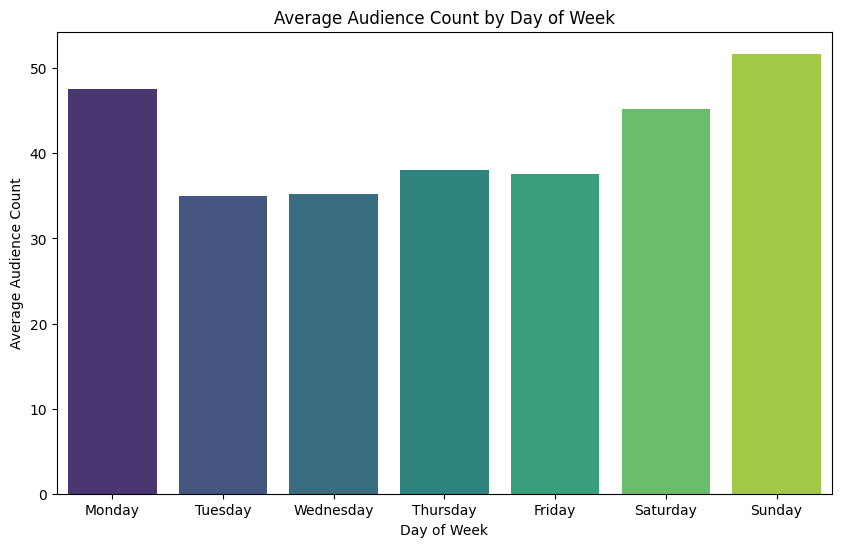

In [12]:
# Map numbers to day names
day_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 
           4:'Friday', 5:'Saturday', 6:'Sunday'}
bnvisit['day_name'] = bnvisit['day_of_week'].map(day_map)

# Average audience per day of week
day_avg = bnvisit.groupby('day_name')['audience_count'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=day_avg.index, y=day_avg.values, palette='viridis')
plt.title('Average Audience Count by Day of Week')
plt.ylabel('Average Audience Count')
plt.xlabel('Day of Week')
plt.show()






<h2 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    Month-wise Audience count
</h2>


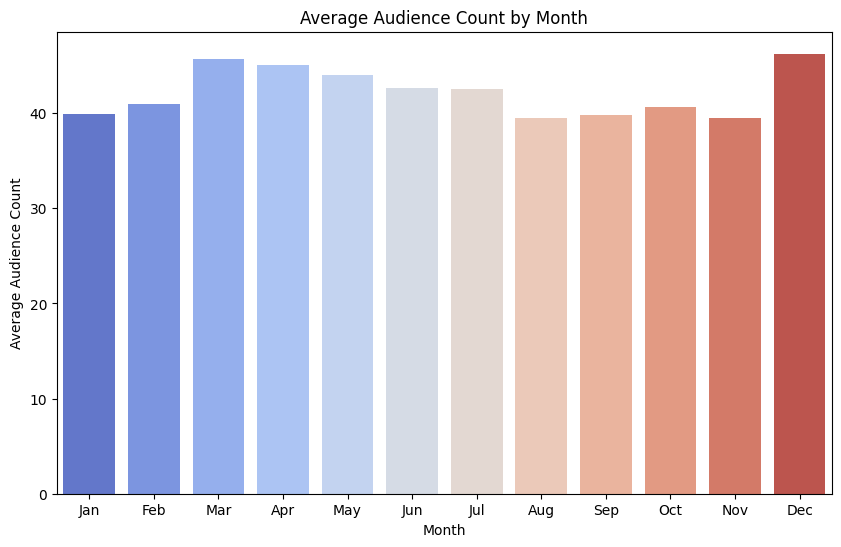

In [13]:
# Average audience per year
month_avg = bnvisit.groupby('month')['audience_count'].mean()

plt.figure(figsize=(10,6))
sns.barplot(x=month_avg.index, y=month_avg.values, palette='coolwarm')
plt.title('Average Audience Count by Month')
plt.ylabel('Average Audience Count')
plt.xlabel('Month')
plt.xticks(range(0,12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()


<h3 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    weekly averages over booking theaters
</h3>


In [14]:
theater_avg = bnvisit.groupby('book_theater_id')['audience_count'].mean().reset_index()
theater_avg.columns = ['book_theater_id', 'avg_audience']
bnvisit = bnvisit.merge(theater_avg, on='book_theater_id', how='left')
ss = ss.merge(theater_avg, on='book_theater_id', how='left')
ss['avg_audience'].fillna(bnvisit['audience_count'].mean(), inplace=True)

/tmp/ipykernel_13/2235556722.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ss['avg_audience'].fillna(bnvisit['audience_count'].mean(), inplace=True)



<h2 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    Scaling & Encoding
</h2>


In [15]:
le = LabelEncoder()
bnvisit['theatre_encoded'] = le.fit_transform(bnvisit['book_theater_id'])
ss['theatre_encoded'] = ss['book_theater_id'].map(
    dict(zip(bnvisit['book_theater_id'], bnvisit['theatre_encoded']))
).fillna(-1).astype(int)

# Prepare Features & Target

features = ['theatre_encoded', 'day', 'month', 'year', 'day_of_week', 'weekend', 'avg_audience']
X = bnvisit[features]
y = bnvisit['audience_count']
X_test = ss[features]
# Scale Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

In [16]:
#from sklearn.preprocessing import OneHotEncoder
#ohe = OneHotEncoder()
#bnvisit['book_theater_id'] = ohe.fit_transform(bnvisit['book_theater_id'])


<h2 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    Initial model Training & Comparision
</h2>


In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle = False)

# Train Multiple Models (excluding Gradient Boosting)

models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'LightGBM': lgb.LGBMRegressor(random_state=42,verbose=-1,force_col_wise=True)
}

initial_results = {}

for name, model in models.items():
    print(f"\n⏳ Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    r2 = r2_score(y_valid, y_pred)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    initial_results[name] = r2
    print(f"✅ {name} | Validation R²: {r2:.4f} | RMSE: {rmse:.2f}")


⏳ Training RandomForest...
✅ RandomForest | Validation R²: 0.3700 | RMSE: 24.38

⏳ Training AdaBoost...
✅ AdaBoost | Validation R²: 0.2990 | RMSE: 25.72

⏳ Training ExtraTrees...
✅ ExtraTrees | Validation R²: 0.3371 | RMSE: 25.01

⏳ Training XGBoost...
✅ XGBoost | Validation R²: 0.4113 | RMSE: 23.57

⏳ Training LightGBM...
✅ LightGBM | Validation R²: 0.4937 | RMSE: 21.86


<h3 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    Hyperparameter Tuning

</h3>


In [18]:
import warnings
warnings.filterwarnings('ignore')


In [19]:
from sklearn.model_selection import GridSearchCV

# -----------------------------
# Step 1: Pick top 3 models
# -----------------------------
top3 = sorted(initial_results, key=initial_results.get, reverse=True)[:3]
print("\n🏆 Top 3 models for hyperparameter tuning:", top3)

# -----------------------------
# Step 2: Define faster grids
# -----------------------------
param_grids = {
    'RandomForest': {
        'n_estimators': [200, 300, 400, 500],       
        'max_depth': [5, 7, 10, None],              
        'min_samples_split': [2, 5, 10],            
        'min_samples_leaf': [1, 2, 4],              
        'max_features': ['auto', 'sqrt', 'log2'],   
        'bootstrap': [True, False]
    },
    'ExtraTrees': {
        'n_estimators': [200, 300, 400, 500],       
        'max_depth': [10, 12, 15, None],            
        'min_samples_split': [2, 5, 10],            
        'min_samples_leaf': [1, 2, 4],              
        'max_features': ['auto', 'sqrt', 'log2'],
        'bootstrap': [True, False]
    },
    'LightGBM': {
        'n_estimators': [200, 300, 500, 800],
        'learning_rate': [0.005, 0.01, 0.05, 0.1],
        'num_leaves': [31, 64, 128, 256],
        'max_depth': [-1, 5, 7, 9, 12],
        'subsample': [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
        'min_child_samples': [20, 40, 80, 160],
        'reg_alpha': [0, 0.01, 0.1, 1],
        'reg_lambda': [0, 0.01, 0.1, 1]
    },
    'AdaBoost': {
        'n_estimators':[50,100],
        'learning_rate':[0.01,0.05,0.1]
    },
    'XGBoost': {
        'n_estimators':[200,300],
        'learning_rate':[0.01,0.05,0.1],
        'max_depth':[3,5,7],
        'subsample':[0.7,0.8,1.0],
        'colsample_bytree':[0.7,0.8,1.0]
    }
}


# -----------------------------
# Step 3: Hyperparameter tuning
# -----------------------------

from sklearn.model_selection import RandomizedSearchCV

best_models = {}

for name in top3:
    print(f"\n⏳ RandomizedSearchCV tuning {name}...")
    model = models[name]
    grid = param_grids[name]

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=grid,
        n_iter=40,         
        scoring='r2',
        cv=2,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    print(f"✅ Best {name} parameters:", search.best_params_)




🏆 Top 3 models for hyperparameter tuning: ['LightGBM', 'XGBoost', 'RandomForest']

⏳ RandomizedSearchCV tuning LightGBM...
Fitting 2 folds for each of 40 candidates, totalling 80 fits
✅ Best LightGBM parameters: {'subsample': 0.7, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 80, 'max_depth': 5, 'learning_rate': 0.005, 'colsample_bytree': 1.0}

⏳ RandomizedSearchCV tuning XGBoost...
Fitting 2 folds for each of 40 candidates, totalling 80 fits
✅ Best XGBoost parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

⏳ RandomizedSearchCV tuning RandomForest...
Fitting 2 folds for each of 40 candidates, totalling 80 fits


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors

✅ Best RandomForest parameters: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'auto', 'max_depth': 5, 'bootstrap': True}


<h3 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    Validation scores after hyperparameter tuning
</h3>


In [20]:
tuned_results = {}
print("\n📊 Validation scores after hyperparameter tuning:")
for name, model in best_models.items():
    y_val_pred = model.predict(X_valid)
    r2 = r2_score(y_valid, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_valid, y_val_pred))
    tuned_results[name] = r2
    print(f"{name} | R²: {r2:.4f} | RMSE: {rmse:.2f}")



📊 Validation scores after hyperparameter tuning:
LightGBM | R²: 0.4996 | RMSE: 21.73
XGBoost | R²: 0.4724 | RMSE: 22.31
RandomForest | R²: 0.4862 | RMSE: 22.02


<h3 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
   Visual comparision of the models
</h3>


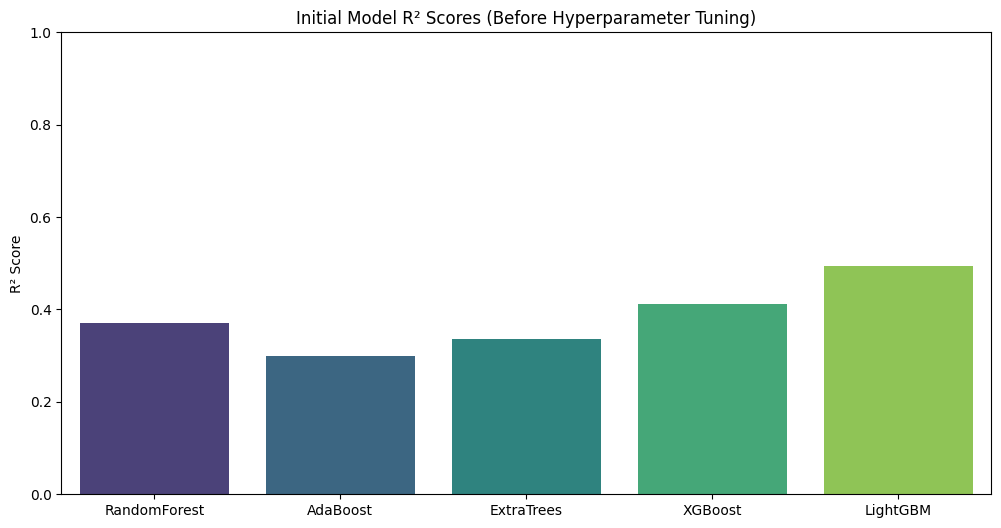

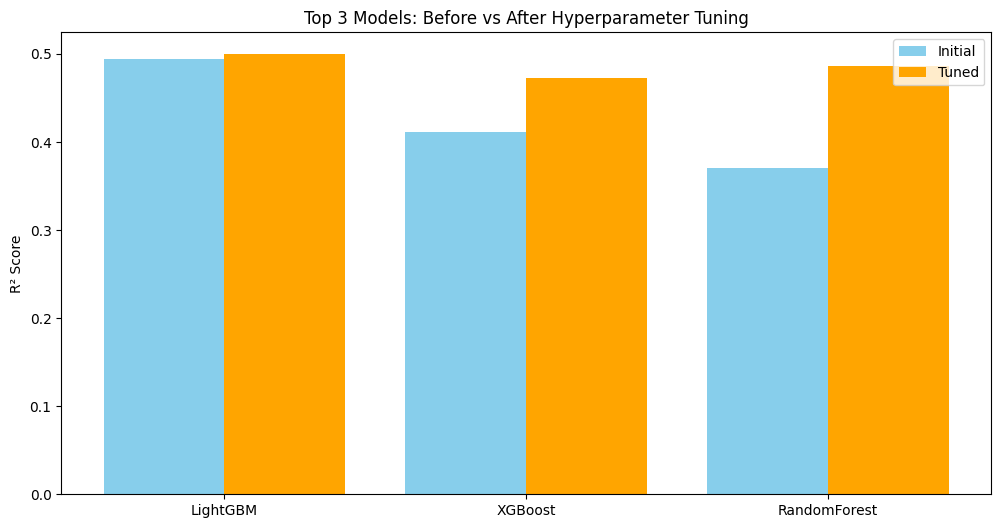

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(x=list(initial_results.keys()), y=list(initial_results.values()), palette="viridis")
plt.title("Initial Model R² Scores (Before Hyperparameter Tuning)")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.show()

plt.figure(figsize=(12,6))
x_labels = list(tuned_results.keys())
initial_vals = [initial_results[name] for name in x_labels]
tuned_vals = [tuned_results[name] for name in x_labels]
x = np.arange(len(x_labels))

plt.bar(x-0.2, initial_vals, width=0.4, label="Initial", color="skyblue")
plt.bar(x+0.2, tuned_vals, width=0.4, label="Tuned", color="orange")
plt.xticks(x, x_labels)
plt.ylabel("R² Score")
plt.title("Top 3 Models: Before vs After Hyperparameter Tuning")
plt.legend()
plt.show()

<h3 style="color:#2E86C1; font-family:Arial, sans-serif; text-align:center;">
    Predicting and Submission 
</h3>


In [22]:
# Pick the best model based on R² score
best_model_name = max(tuned_results, key=tuned_results.get)
best_model = best_models[best_model_name]

print(f"\n🏆 Best Model Selected: {best_model_name}")



🏆 Best Model Selected: LightGBM


In [23]:
print("\n📊 Step 9/10: Evaluating best model performance...")
y_val_pred = best_model.predict(X_valid)

r2 = r2_score(y_valid, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_val_pred))

print(f"{best_model_name} | R²: {r2:.4f} | RMSE: {rmse:.2f}")



📊 Step 9/10: Evaluating best model performance...
LightGBM | R²: 0.4996 | RMSE: 21.73


In [24]:
print("\n🧮 Step 10/10: Predicting and saving submission file...")

ss['audience_count'] = best_model.predict(X_test_scaled).round().astype(int)

final = ss[['ID', 'audience_count']]
final.to_csv('best_model_scaled_predictions.csv', index=False)

print("✅ Saved submission to best_model_scaled_predictions.csv")

final



🧮 Step 10/10: Predicting and saving submission file...
✅ Saved submission to best_model_scaled_predictions.csv


,ID,audience_count
0,book_00001_2024-03-01,41
1,book_00001_2024-03-02,55
2,book_00001_2024-03-03,63
3,book_00001_2024-03-04,49
4,book_00001_2024-03-06,36
...,...,...
38057,book_00829_2024-04-18,12
38058,book_00829_2024-04-19,12
38059,book_00829_2024-04-20,13
38060,book_00829_2024-04-21,14
